<a href="https://colab.research.google.com/github/solven139/Projects/blob/main/ML_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df_peek = pd.read_csv('/content/drive/MyDrive/loan.csv', nrows=5)
print(df_peek.shape)
print(df_peek.columns.tolist())

(5, 145)
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m'

In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/loan.csv', nrows=50000, low_memory=False)

print(df['loan_status'].value_counts())

loan_status
Current               48708
Fully Paid             1036
In Grace Period         113
Late (31-120 days)       86
Late (16-30 days)        54
Charged Off               3
Name: count, dtype: int64


In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.read_csv('/content/drive/MyDrive/loan.csv',
                 skiprows=lambda x: x > 0 and np.random.random() > 0.1,
                 low_memory=False)

print(f"讀取筆數：{len(df)}")
print("\nloan_status 分布：")
print(df['loan_status'].value_counts())

讀取筆數：225889

loan_status 分布：
loan_status
Fully Paid                                             104023
Current                                                 92007
Charged Off                                             26172
Late (31-120 days)                                       2154
In Grace Period                                           893
Late (16-30 days)                                         352
Does not meet the credit policy. Status:Fully Paid        207
Does not meet the credit policy. Status:Charged Off        78
Default                                                     3
Name: count, dtype: int64


In [6]:
df = df[df['loan_status'] != 'Current']

default_status = [
    'Charged Off',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'In Grace Period',
    'Default',
    'Does not meet the credit policy. Status:Charged Off'
]

df['target'] = df['loan_status'].apply(
    lambda x: 1 if x in default_status else 0
)

print(f"剩餘筆數：{len(df)}")
print(f"\n目標變數分布：")
print(df['target'].value_counts())
print(f"\n違約比例：{df['target'].mean():.1%}")

剩餘筆數：133882

目標變數分布：
target
0    104230
1     29652
Name: count, dtype: int64

違約比例：22.1%


In [7]:
features = [

    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'purpose',


    'annual_inc',
    'dti',
    'emp_length',


    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
]

df_model = df[features + ['target']].copy()

print("特徵資料概況：")
print(df_model.shape)
print("\n缺失值：")
print(df_model.isnull().sum())
print("\n各特徵資料型態：")
print(df_model.dtypes)

特徵資料概況：
(133882, 17)

缺失值：
loan_amnt            0
term                 0
int_rate             0
installment          0
grade                0
purpose              0
annual_inc           0
dti                 30
emp_length        7858
delinq_2yrs          5
inq_last_6mths       6
open_acc             5
pub_rec              5
revol_bal            0
revol_util          88
total_acc            5
target               0
dtype: int64

各特徵資料型態：
loan_amnt           int64
term               object
int_rate          float64
installment       float64
grade              object
purpose            object
annual_inc        float64
dti               float64
emp_length         object
delinq_2yrs       float64
inq_last_6mths    float64
open_acc          float64
pub_rec           float64
revol_bal           int64
revol_util        float64
total_acc         float64
target              int64
dtype: object


In [8]:
import numpy as np

df_clean = df_model.copy()

df_clean['term'] = df_clean['term'].str.extract('(\d+)').astype(int)

emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4,  '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8,  '9 years': 9, '10+ years': 10
}
df_clean['emp_length'] = df_clean['emp_length'].map(emp_map)

grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
df_clean['grade'] = df_clean['grade'].map(grade_map)

df_clean = pd.get_dummies(df_clean, columns=['purpose'], drop_first=True)

df_clean['emp_length'] = df_clean['emp_length'].fillna(
    df_clean['emp_length'].median()
)
df_clean['revol_util'] = df_clean['revol_util'].fillna(
    df_clean['revol_util'].median()
)
df_clean['dti'] = df_clean['dti'].fillna(df_clean['dti'].median())

df_clean = df_clean.dropna()


print(f"前處理後筆數：{len(df_clean)}")
print(f"前處理後欄位數：{df_clean.shape[1]}")
print(f"\n還有缺失值嗎：{df_clean.isnull().sum().sum()}")
print(f"\n違約比例：{df_clean['target'].mean():.1%}")
print(f"\n Data type：")
print(df_clean.dtypes)

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5284/2447549614.py:5: SyntaxWarning: invalid escape sequence '\d'
  df_clean['term'] = df_clean['term'].str.extract('(\d+)').astype(int)


前處理後筆數：133876
前處理後欄位數：29

還有缺失值嗎：0

違約比例：22.1%

 Data type：
loan_amnt                       int64
term                            int64
int_rate                      float64
installment                   float64
grade                           int64
annual_inc                    float64
dti                           float64
emp_length                    float64
delinq_2yrs                   float64
inq_last_6mths                float64
open_acc                      float64
pub_rec                       float64
revol_bal                       int64
revol_util                    float64
total_acc                     float64
target                          int64
purpose_credit_card              bool
purpose_debt_consolidation       bool
purpose_educational              bool
purpose_home_improvement         bool
purpose_house                    bool
purpose_major_purchase           bool
purpose_medical                  bool
purpose_moving                   bool
purpose_other               

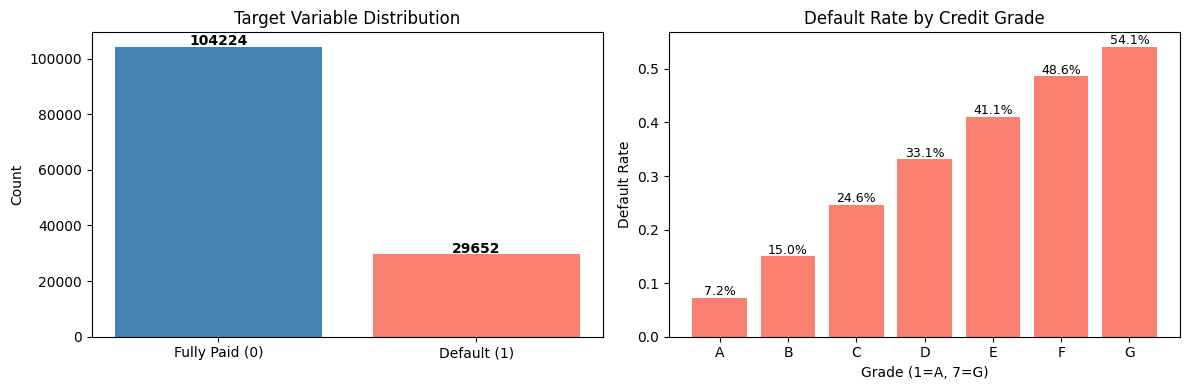

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 目標變數分布
axes[0].bar(['Fully Paid (0)', 'Default (1)'],
            df_clean['target'].value_counts().sort_index(),
            color=['steelblue', 'salmon'])
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(df_clean['target'].value_counts().sort_index()):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# 違約率 by 信用評級
grade_default = df_clean.groupby('grade')['target'].mean()
grade_labels  = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
axes[1].bar(grade_labels, grade_default.values, color='salmon')
axes[1].set_title('Default Rate by Credit Grade')
axes[1].set_xlabel('Grade (1=A, 7=G)')
axes[1].set_ylabel('Default Rate')
for i, v in enumerate(grade_default.values):
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5284/2440285419.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_plot, x='target', y='annual_inc',


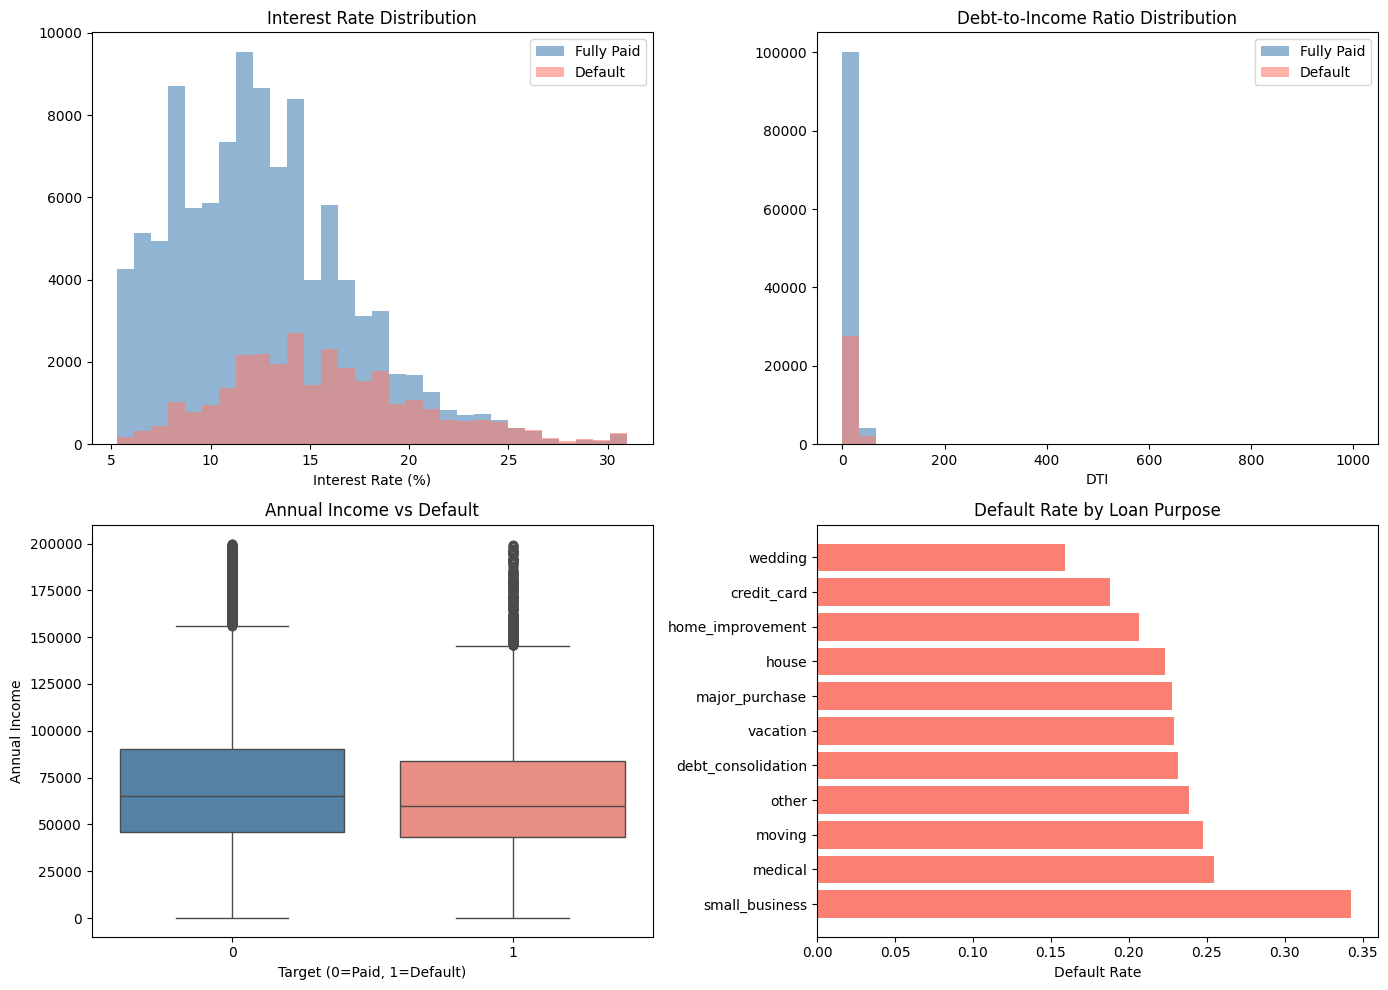

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 利率分布
axes[0,0].hist(df_clean[df_clean['target']==0]['int_rate'],
               bins=30, alpha=0.6, color='steelblue', label='Fully Paid')
axes[0,0].hist(df_clean[df_clean['target']==1]['int_rate'],
               bins=30, alpha=0.6, color='salmon', label='Default')
axes[0,0].set_title('Interest Rate Distribution')
axes[0,0].set_xlabel('Interest Rate (%)')
axes[0,0].legend()

# DTI 分布
axes[0,1].hist(df_clean[df_clean['target']==0]['dti'],
               bins=30, alpha=0.6, color='steelblue', label='Fully Paid')
axes[0,1].hist(df_clean[df_clean['target']==1]['dti'],
               bins=30, alpha=0.6, color='salmon', label='Default')
axes[0,1].set_title('Debt-to-Income Ratio Distribution')
axes[0,1].set_xlabel('DTI')
axes[0,1].legend()

# 年收入 vs 違約（用 boxplot）
df_clean_plot = df_clean[df_clean['annual_inc'] < 200000]  # 移除極端值
sns.boxplot(data=df_clean_plot, x='target', y='annual_inc',
            palette=['steelblue', 'salmon'], ax=axes[1,0])
axes[1,0].set_title('Annual Income vs Default')
axes[1,0].set_xlabel('Target (0=Paid, 1=Default)')
axes[1,0].set_ylabel('Annual Income')

# 違約率 by 貸款目的（前8名）
purpose_cols = [c for c in df_clean.columns if c.startswith('purpose_')]
purpose_default = {}
for col in purpose_cols:
    mask = df_clean[col] == True
    if mask.sum() > 100:
        name = col.replace('purpose_', '')
        purpose_default[name] = df_clean[mask]['target'].mean()

purpose_df = pd.Series(purpose_default).sort_values(ascending=False)
axes[1,1].barh(purpose_df.index, purpose_df.values, color='salmon')
axes[1,1].set_title('Default Rate by Loan Purpose')
axes[1,1].set_xlabel('Default Rate')

plt.tight_layout()
plt.show()

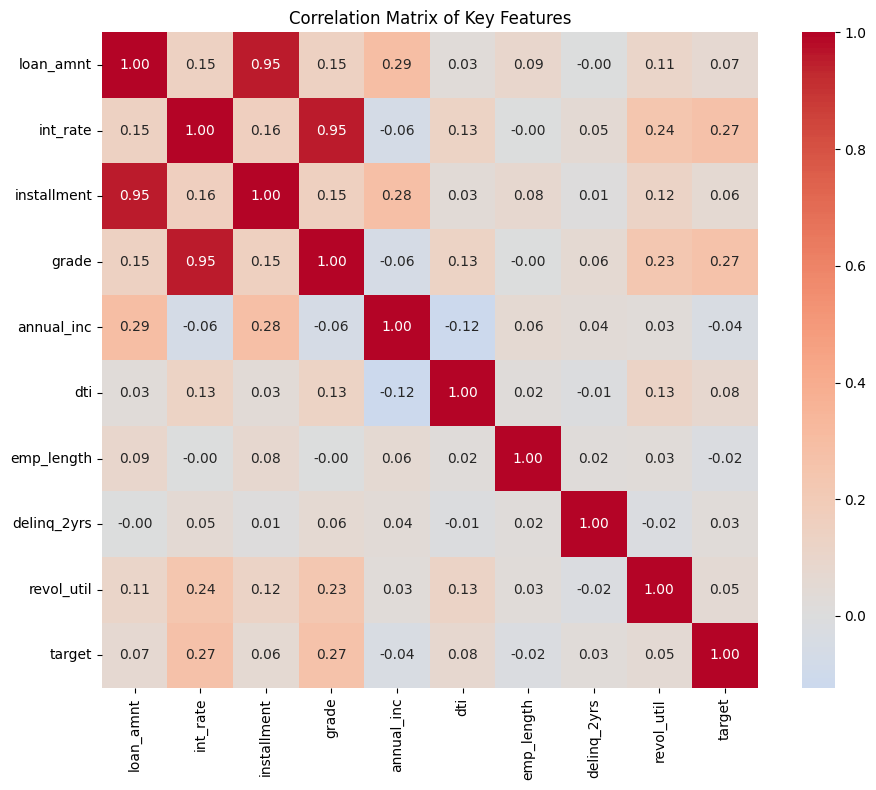

與違約相關性排名：
int_rate       0.267240
grade          0.266187
dti            0.075125
loan_amnt      0.072862
installment    0.058780
revol_util     0.050089
annual_inc     0.035347
delinq_2yrs    0.027249
emp_length     0.018348
Name: target, dtype: float64


In [11]:
numeric_cols = ['loan_amnt', 'int_rate', 'installment', 'grade',
                'annual_inc', 'dti', 'emp_length', 'delinq_2yrs',
                'revol_util', 'target']

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Correlation Matrix of Key Features')
plt.tight_layout()
plt.show()

# 印出跟 target 相關性最高的特徵
print("與違約相關性排名：")
print(corr['target'].abs().sort_values(ascending=False)[1:])

DTI 統計：
count    133876.000000
mean         18.327837
std          12.270582
min           0.000000
25%          11.790000
50%          17.640000
75%          24.100000
max         999.000000
Name: dti, dtype: float64

DTI > 100 的筆數：62
DTI > 60 的筆數：183

移除極端值後筆數：133693


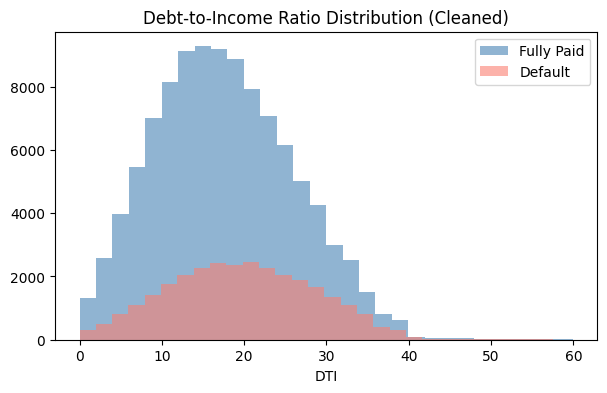

In [12]:
# 查看 DTI 的分布
print("DTI 統計：")
print(df_clean['dti'].describe())
print(f"\nDTI > 100 的筆數：{(df_clean['dti'] > 100).sum()}")
print(f"DTI > 60 的筆數：{(df_clean['dti'] > 60).sum()}")

# 修正：移除 DTI 超過 60 的極端值（業界標準上限約 50）
df_clean = df_clean[df_clean['dti'] <= 60]
print(f"\n移除極端值後筆數：{len(df_clean)}")

# 重新畫 DTI 圖確認
plt.figure(figsize=(7, 4))
plt.hist(df_clean[df_clean['target']==0]['dti'],
         bins=30, alpha=0.6, color='steelblue', label='Fully Paid')
plt.hist(df_clean[df_clean['target']==1]['dti'],
         bins=30, alpha=0.6, color='salmon', label='Default')
plt.title('Debt-to-Income Ratio Distribution (Cleaned)')
plt.xlabel('DTI')
plt.legend()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 分出 X 和 y
X = df_clean.drop(['target', 'loan_status']
                  if 'loan_status' in df_clean.columns
                  else ['target'], axis=1)
y = df_clean['target']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"違約比例: {y.mean():.1%}")

# 切割資料
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining Set: {X_train.shape[0]} 筆")
print(f"Test Set:     {X_test.shape[0]} 筆")

# 標準化（Logistic Regression 需要）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ 資料準備完成！")

X shape: (133693, 28)
y shape: (133693,)
違約比例: 22.1%

Training Set: 106954 筆
Test Set:     26739 筆

✅ 資料準備完成！


訓練 Logistic Regression...

===== Logistic Regression Results =====
              precision    recall  f1-score   support

  Fully Paid       0.79      0.98      0.87     20820
     Default       0.55      0.10      0.17      5919

    accuracy                           0.78     26739
   macro avg       0.67      0.54      0.52     26739
weighted avg       0.74      0.78      0.72     26739

ROC-AUC Score: 0.6960


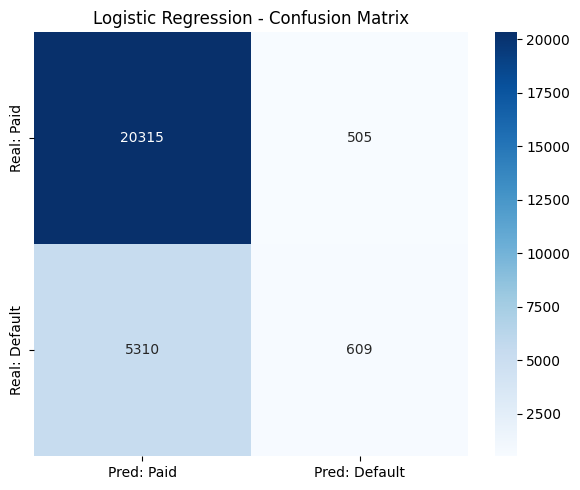

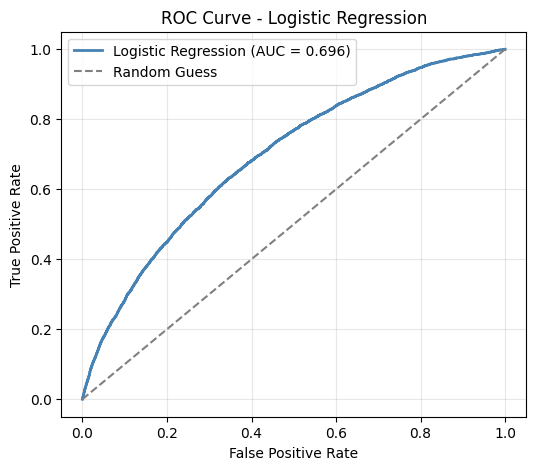

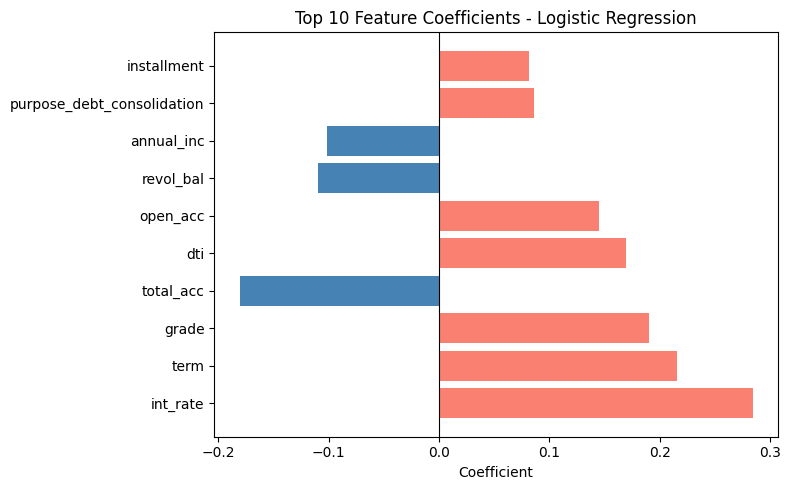


正係數（紅）= 增加違約機率
負係數（藍）= 降低違約機率


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Model 1：Logistic Regression
# ============================================

print("訓練 Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 預測
lr_pred       = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# 評估
print("\n===== Logistic Regression Results =====")
print(classification_report(y_test, lr_pred,
      target_names=['Fully Paid', 'Default']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_pred_proba):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Paid', 'Pred: Default'],
            yticklabels=['Real: Paid', 'Real: Default'])
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_pred_proba)
auc_score   = roc_auc_score(y_test, lr_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Guess')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Feature Importance（係數）
feature_names = X.columns.tolist()
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

plt.figure(figsize=(8, 5))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 10 Feature Coefficients - Logistic Regression')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

print("\n正係數（紅）= 增加違約機率")
print("負係數（藍）= 降低違約機率")

訓練 Random Forest...（需要約1-2分鐘）

===== Random Forest Results =====
              precision    recall  f1-score   support

  Fully Paid       0.79      0.97      0.87     20820
     Default       0.51      0.09      0.16      5919

    accuracy                           0.78     26739
   macro avg       0.65      0.53      0.52     26739
weighted avg       0.73      0.78      0.71     26739

ROC-AUC Score: 0.6854


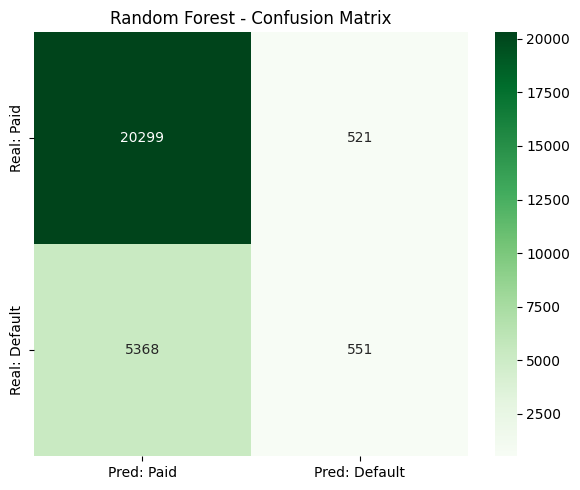

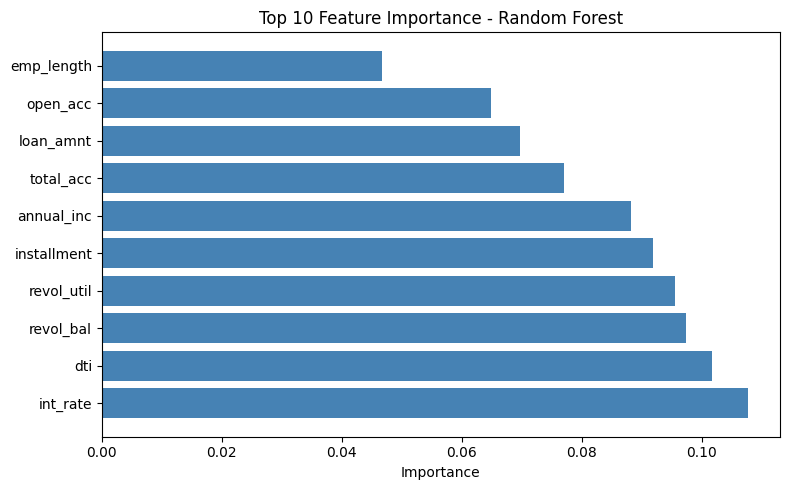

In [15]:
from sklearn.ensemble import RandomForestClassifier

# ============================================
# Model 2：Random Forest
# ============================================

print("訓練 Random Forest...（需要約1-2分鐘）")
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100棵樹
    random_state=42,
    n_jobs=-1            # 用所有CPU核心加速
)
rf_model.fit(X_train, y_train)  # 注意：用未縮放的資料

# 預測
rf_pred       = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# 評估
print("\n===== Random Forest Results =====")
print(classification_report(y_test, rf_pred,
      target_names=['Fully Paid', 'Default']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_pred_proba):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred: Paid', 'Pred: Default'],
            yticklabels=['Real: Paid', 'Real: Default'])
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature Importance
fi_df = pd.DataFrame({
    'Feature':   X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [16]:
# ============================================
# 改善：加入 class_weight='balanced'
# ============================================

print("訓練改善版本...")

# Logistic Regression with class_weight
lr_balanced = LogisticRegression(
    max_iter=1000, random_state=42,
    class_weight='balanced'
)
lr_balanced.fit(X_train_scaled, y_train)
lr_bal_pred       = lr_balanced.predict(X_test_scaled)
lr_bal_pred_proba = lr_balanced.predict_proba(X_test_scaled)[:, 1]

# Random Forest with class_weight
rf_balanced = RandomForestClassifier(
    n_estimators=100, random_state=42,
    n_jobs=-1, class_weight='balanced'
)
rf_balanced.fit(X_train, y_train)
rf_bal_pred       = rf_balanced.predict(X_test)
rf_bal_pred_proba = rf_balanced.predict_proba(X_test)[:, 1]

# 印出比較
print("\n===== Logistic Regression (Balanced) =====")
print(classification_report(y_test, lr_bal_pred,
      target_names=['Fully Paid', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_bal_pred_proba):.4f}")

print("\n===== Random Forest (Balanced) =====")
print(classification_report(y_test, rf_bal_pred,
      target_names=['Fully Paid', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_bal_pred_proba):.4f}")

訓練改善版本...

===== Logistic Regression (Balanced) =====
              precision    recall  f1-score   support

  Fully Paid       0.86      0.67      0.75     20820
     Default       0.34      0.62      0.44      5919

    accuracy                           0.65     26739
   macro avg       0.60      0.64      0.60     26739
weighted avg       0.75      0.65      0.68     26739

ROC-AUC: 0.6962

===== Random Forest (Balanced) =====
              precision    recall  f1-score   support

  Fully Paid       0.79      0.98      0.87     20820
     Default       0.50      0.07      0.12      5919

    accuracy                           0.78     26739
   macro avg       0.65      0.52      0.49     26739
weighted avg       0.72      0.78      0.71     26739

ROC-AUC: 0.6853


訓練 Decision Tree...

===== Decision Tree Results =====
              precision    recall  f1-score   support

  Fully Paid       0.80      0.80      0.80     20820
     Default       0.29      0.29      0.29      5919

    accuracy                           0.69     26739
   macro avg       0.54      0.54      0.54     26739
weighted avg       0.69      0.69      0.69     26739

ROC-AUC: 0.5442


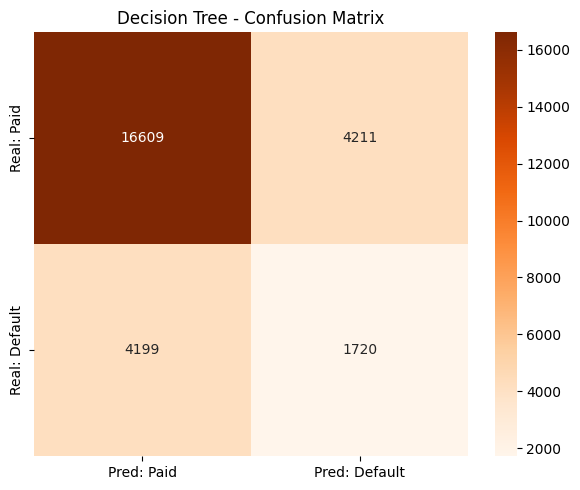

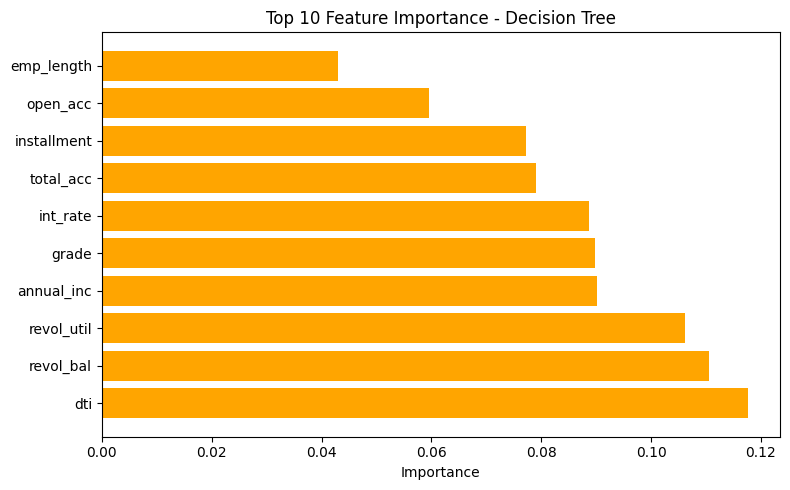

In [17]:
from sklearn.tree import DecisionTreeClassifier

# ============================================
# Model 3：Decision Tree
# ============================================

print("訓練 Decision Tree...")
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train, y_train)

dt_pred       = dt_model.predict(X_test)
dt_pred_proba = dt_model.predict_proba(X_test)[:, 1]

print("\n===== Decision Tree Results =====")
print(classification_report(y_test, dt_pred,
      target_names=['Fully Paid', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, dt_pred_proba):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred: Paid', 'Pred: Default'],
            yticklabels=['Real: Paid', 'Real: Default'])
plt.title('Decision Tree - Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature Importance
fi_dt = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(fi_dt['Feature'], fi_dt['Importance'], color='orange')
plt.title('Top 10 Feature Importance - Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# ============================================
# Hyperparameter Tuning：RandomizedSearchCV
# ============================================

# 只對表現較好的 LR Balanced 做調整
param_dist = {
    'C':        [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty':  ['l1', 'l2'],
    'solver':   ['liblinear', 'saga'],
}

print("執行 RandomizedSearchCV...（約2-3分鐘）")

lr_tuned = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42,
                       class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=20,           # 嘗試20種組合
    cv=5,                # 5-fold cross validation
    scoring='f1',        # 以 F1 為優化目標
    random_state=42,
    n_jobs=-1
)

lr_tuned.fit(X_train_scaled, y_train)

print(f"\n最佳參數：{lr_tuned.best_params_}")
print(f"最佳 CV F1：{lr_tuned.best_score_:.4f}")

# 用最佳模型預測
best_pred       = lr_tuned.best_estimator_.predict(X_test_scaled)
best_pred_proba = lr_tuned.best_estimator_.predict_proba(X_test_scaled)[:, 1]

print("\n===== Tuned Logistic Regression Results =====")
print(classification_report(y_test, best_pred,
      target_names=['Fully Paid', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, best_pred_proba):.4f}")

執行 RandomizedSearchCV...（約2-3分鐘）

最佳參數：{'solver': 'saga', 'penalty': 'l1', 'C': 0.1}
最佳 CV F1：0.4463

===== Tuned Logistic Regression Results =====
              precision    recall  f1-score   support

  Fully Paid       0.86      0.67      0.75     20820
     Default       0.34      0.62      0.44      5919

    accuracy                           0.65     26739
   macro avg       0.60      0.64      0.60     26739
weighted avg       0.75      0.65      0.68     26739

ROC-AUC: 0.6962


In [20]:
from sklearn.model_selection import RandomizedSearchCV

# ============================================
# Hyperparameter Tuning：Random Forest
# ============================================

rf_param_dist = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight':      ['balanced', None]
}

print("執行 RF RandomizedSearchCV...（約3-5分鐘）")

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

print(f"\n最佳參數：{rf_tuned.best_params_}")
print(f"最佳 CV F1：{rf_tuned.best_score_:.4f}")

rf_tuned_pred       = rf_tuned.best_estimator_.predict(X_test)
rf_tuned_pred_proba = rf_tuned.best_estimator_.predict_proba(X_test)[:, 1]

print("\n===== RF Tuned Results =====")
print(classification_report(y_test, rf_tuned_pred,
      target_names=['Fully Paid', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_tuned_pred_proba):.4f}")

執行 RF RandomizedSearchCV...（約3-5分鐘）

最佳參數：{'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10, 'class_weight': 'balanced'}
最佳 CV F1：0.4453

===== RF Tuned Results =====
              precision    recall  f1-score   support

  Fully Paid       0.86      0.65      0.74     20820
     Default       0.34      0.63      0.44      5919

    accuracy                           0.64     26739
   macro avg       0.60      0.64      0.59     26739
weighted avg       0.74      0.64      0.67     26739

ROC-AUC: 0.6967


===== Final Model Comparison =====
               Accuracy  Precision  Recall     F1    AUC
Model                                                   
LR (Original)     0.783      0.547   0.103  0.173  0.696
LR (Balanced)     0.655      0.344   0.617  0.441  0.696
LR (Tuned)        0.655      0.344   0.617  0.442  0.696
RF (Original)     0.780      0.514   0.093  0.158  0.685
RF (Tuned)        0.644      0.337   0.628  0.439  0.697
Decision Tree     0.685      0.290   0.291  0.290  0.544


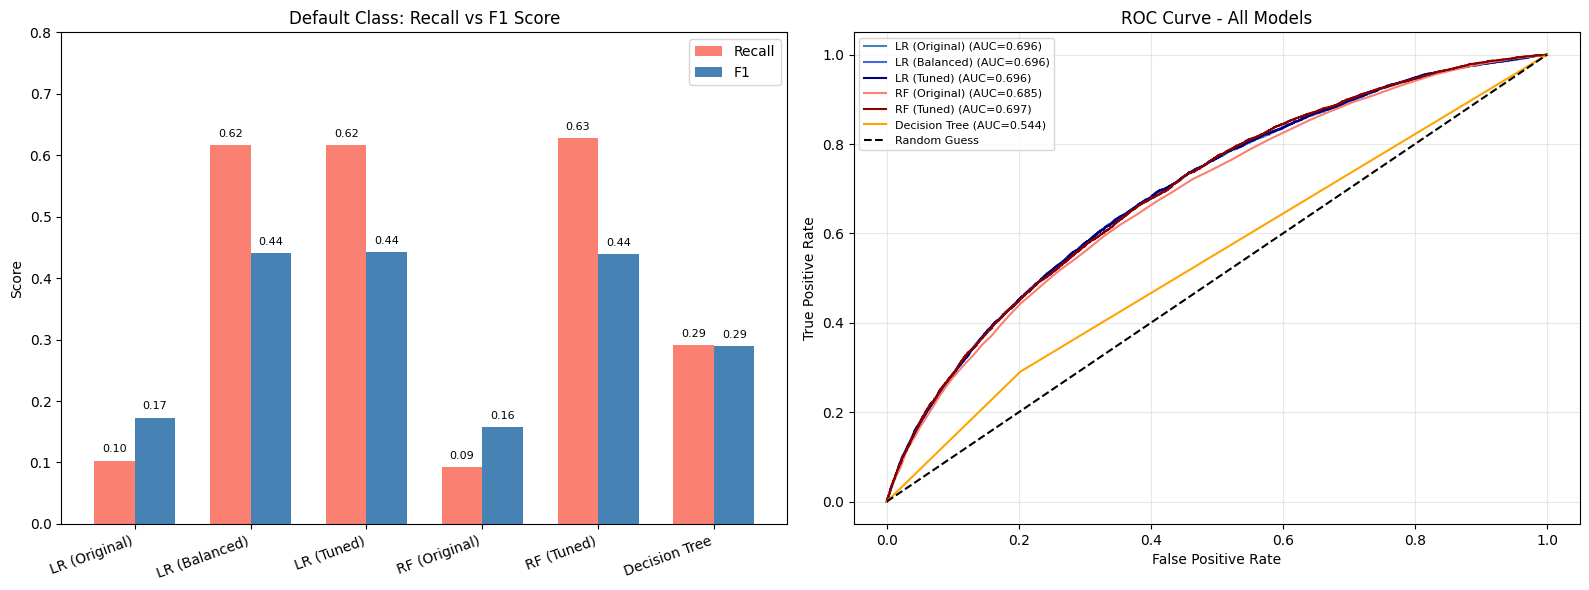

In [22]:
# ============================================
# 更新最終比較（加入 DT 和 RF Tuned）
# ============================================

models_final = {
    'LR (Original)':  (lr_pred, lr_pred_proba),
    'LR (Balanced)':  (lr_bal_pred, lr_bal_pred_proba),
    'LR (Tuned)':     (best_pred, best_pred_proba),
    'RF (Original)':  (rf_pred, rf_pred_proba),
    'RF (Tuned)':     (rf_tuned_pred, rf_tuned_pred_proba),
    'Decision Tree':  (dt_pred, dt_pred_proba),
}

rows = []
for name, (pred, proba) in models_final.items():
    rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1':        f1_score(y_test, pred),
        'AUC':       roc_auc_score(y_test, proba)
    })

results_final = pd.DataFrame(rows).set_index('Model').round(3)
print("===== Final Model Comparison =====")
print(results_final)

# ============================================
# 最終比較圖
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左圖：Recall 和 F1
x     = np.arange(len(results_final))
width = 0.35

bars1 = axes[0].bar(x - width/2, results_final['Recall'],
                    width, label='Recall', color='salmon')
bars2 = axes[0].bar(x + width/2, results_final['F1'],
                    width, label='F1', color='steelblue')

axes[0].set_title('Default Class: Recall vs F1 Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_final.index, rotation=20, ha='right')
axes[0].set_ylim(0, 0.8)
axes[0].legend()
axes[0].set_ylabel('Score')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=8)

# 右圖：ROC Curve
colors = ['steelblue', 'royalblue', 'navy',
          'salmon', 'darkred', 'orange']

for (name, (pred, proba)), color in zip(models_final.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, linewidth=1.5, color=color,
                 label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1], [0,1], 'k--', label='Random Guess')
axes[1].set_title('ROC Curve - All Models')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# ============================================
# 更新結論
# ============================================

print("""
===== Final Conclusions =====

BEST MODEL: RF (Tuned)
  AUC: 0.697, Default Recall: 0.630, F1: 0.440

MODEL RANKING:
  1. RF Tuned    → AUC 0.697, Recall 0.630 (Best Overall)
  2. LR Tuned    → AUC 0.696, Recall 0.617
  3. RF Original → AUC 0.685, Recall 0.093
  4. LR Original → AUC 0.696, Recall 0.103
  5. Decision Tree → AUC 0.544, Recall 0.290

KEY FINDINGS:
  1. Hyperparameter tuning dramatically improved RF:
     Recall from 0.093 → 0.630 (+538%)

  2. Decision Tree showed clear overfitting (AUC 0.544)
     Random Forest overcomes this via ensemble averaging

  3. Interest rate and DTI are consistently the most
     important features across all models

  4. Class imbalance (22% default) is the main challenge
     Both class_weight and max_depth tuning are essential
""")


===== Final Conclusions =====

BEST MODEL: RF (Tuned)
  AUC: 0.697, Default Recall: 0.630, F1: 0.440

MODEL RANKING:
  1. RF Tuned    → AUC 0.697, Recall 0.630 (Best Overall)
  2. LR Tuned    → AUC 0.696, Recall 0.617
  3. RF Original → AUC 0.685, Recall 0.093
  4. LR Original → AUC 0.696, Recall 0.103
  5. Decision Tree → AUC 0.544, Recall 0.290

KEY FINDINGS:
  1. Hyperparameter tuning dramatically improved RF:
     Recall from 0.093 → 0.630 (+538%)
  
  2. Decision Tree showed clear overfitting (AUC 0.544)
     Random Forest overcomes this via ensemble averaging
  
  3. Interest rate and DTI are consistently the most
     important features across all models
  
  4. Class imbalance (22% default) is the main challenge
     Both class_weight and max_depth tuning are essential

